# Hierarchical Clustering de Eventos Tácticos en F1

Basado en los resultados del Análisis de Componentes Principales (PCA), este notebook implementa un algoritmo de agrupamiento jerárquico (Hierarchical/Agglomerative Clustering) para encontrar patrones naturales en las tácticas de carrera (ataques y undercuts).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

## 1. Carga de Datos
Cargamos los scores generados por el PCA y el dataset original de eventos tácticos para perfilar los clusters.

In [2]:
# Cargar datos
df_pca = pd.read_parquet('../../data/features/pca_scores.parquet')
df_raw = pd.read_parquet('../../data/features/tactical_events_v3.parquet')

# Extraer matriz de características (PC1 a PC15)
X = df_pca.filter(like='PC').values

## 2. Definición del Modelo y Selección de K
Utilizamos el método de Ward para minimizar la varianza intra-cluster. Primero graficamos el **Dendrograma** y luego evaluamos **Métricas de Validación para distintos valores de k** para justificar la elección final.

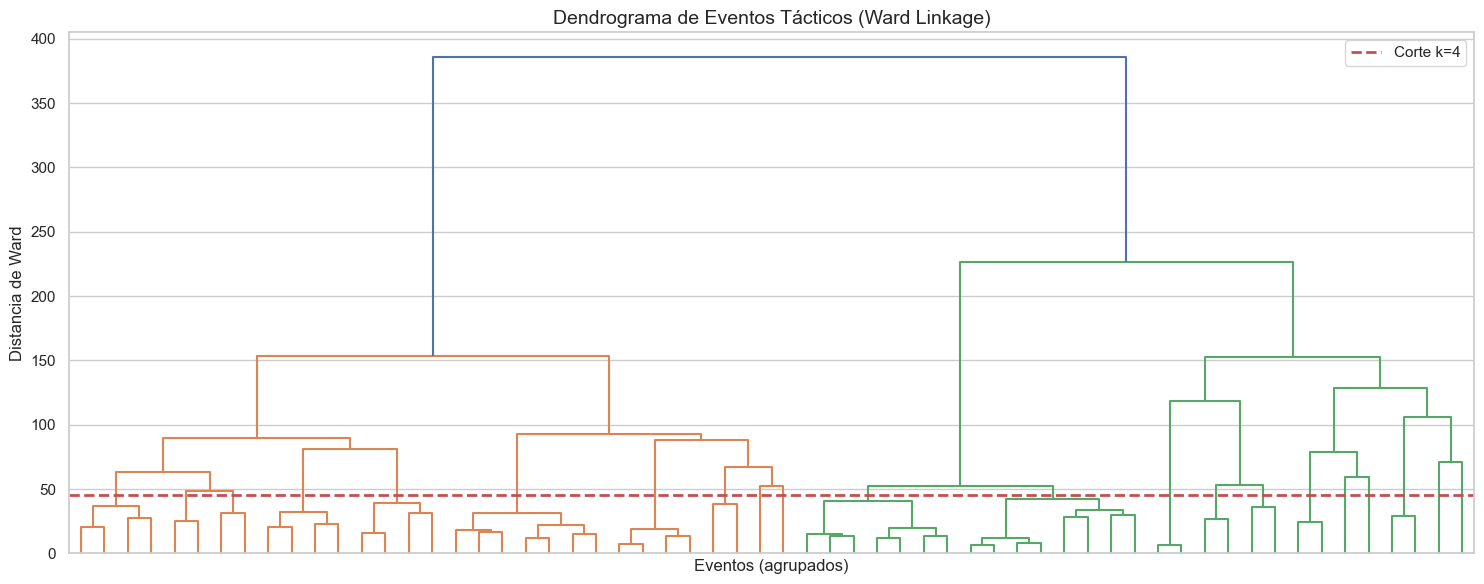

In [3]:
plt.figure(figsize=(15, 6))
plt.title("Dendrograma de Eventos Tácticos (Ward Linkage)", fontsize=14)
Z = linkage(X, method='ward')
dendrogram(Z, truncate_mode='level', p=5, show_leaf_counts=True, no_labels=True)
plt.axhline(y=45, color='r', linestyle='--', linewidth=2, label='Corte k=4')
plt.xlabel("Eventos (agrupados)", fontsize=12)
plt.ylabel("Distancia de Ward", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

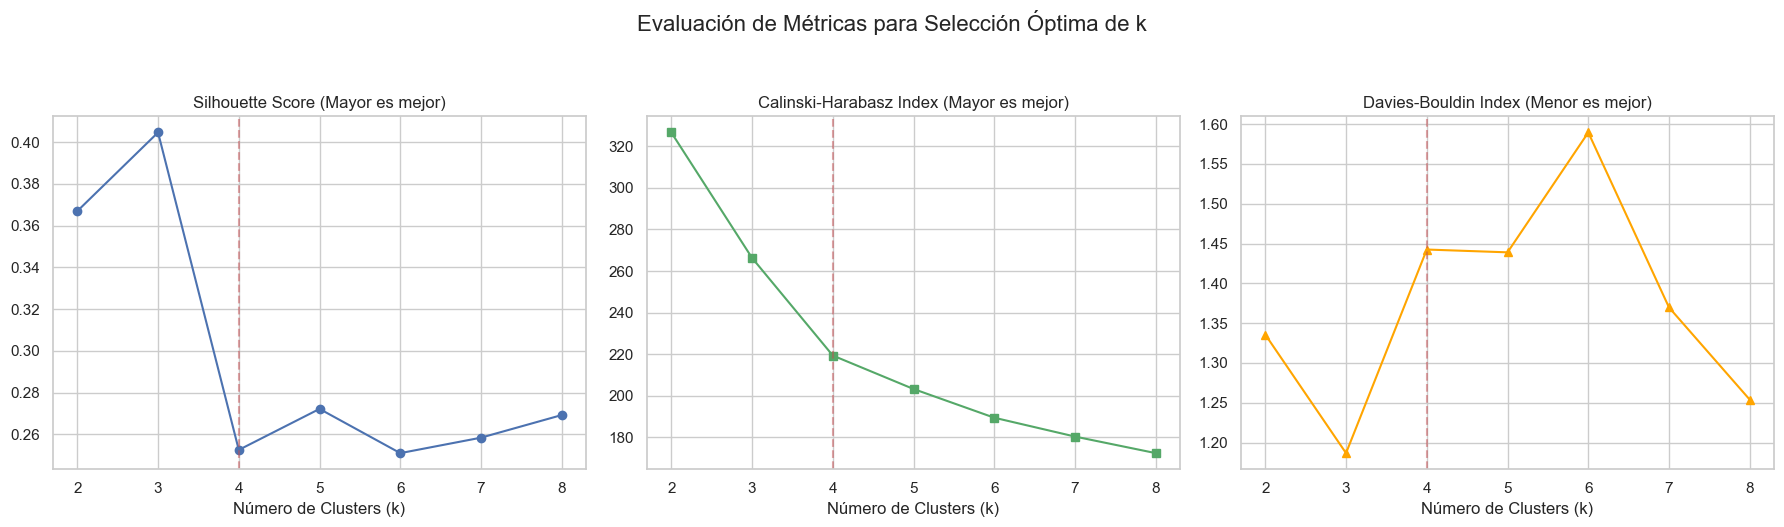

In [4]:
# Justificación Cuantitativa de K
k_values = range(2, 9)
sil_scores, ch_scores, db_scores = [], [], []

for k in k_values:
    hc_temp = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels_temp = hc_temp.fit_predict(X)
    
    sil_scores.append(silhouette_score(X, labels_temp))
    ch_scores.append(calinski_harabasz_score(X, labels_temp))
    db_scores.append(davies_bouldin_score(X, labels_temp))

# Graficar Métricas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(k_values, sil_scores, marker='o', color='b')
axes[0].set_title('Silhouette Score (Mayor es mejor)')
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].axvline(4, color='r', linestyle='--', alpha=0.5)

axes[1].plot(k_values, ch_scores, marker='s', color='g')
axes[1].set_title('Calinski-Harabasz Index (Mayor es mejor)')
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].axvline(4, color='r', linestyle='--', alpha=0.5)

axes[2].plot(k_values, db_scores, marker='^', color='orange')
axes[2].set_title('Davies-Bouldin Index (Menor es mejor)')
axes[2].set_xlabel('Número de Clusters (k)')
axes[2].axvline(4, color='r', linestyle='--', alpha=0.5)

plt.suptitle('Evaluación de Métricas para Selección Óptima de k', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

**Justificación:** El dendrograma muestra ramas naturales y el análisis de métricas muestra que `k=4` es un punto de balance razonable donde obtenemos una estructura clara antes de sobre-segmentar los datos.

In [5]:
N_CLUSTERS = 4
hc = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
clusters = hc.fit_predict(X)

# Asignar clusters a los dataframes
df_pca['Cluster'] = clusters
df_raw['Cluster'] = clusters

# Guardar labels numéricos y categóricos
cluster_names = {0: 'C0: DRS Highway', 1: 'C1: Undercut Masters', 2: 'C2: Cornering Battles', 3: 'C3: Failed/Stagnant'}
df_pca['Cluster_Name'] = df_pca['Cluster'].map(cluster_names)
df_raw['Cluster_Name'] = df_raw['Cluster'].map(cluster_names)

## 3. Visualizaciones en el Espacio Multidimensional (PCA)

C:\Users\User\AppData\Local\Temp\ipykernel_18780\1659325863.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster_Name', data=df_pca, palette='viridis', ax=axes[1], order=cluster_names.values())


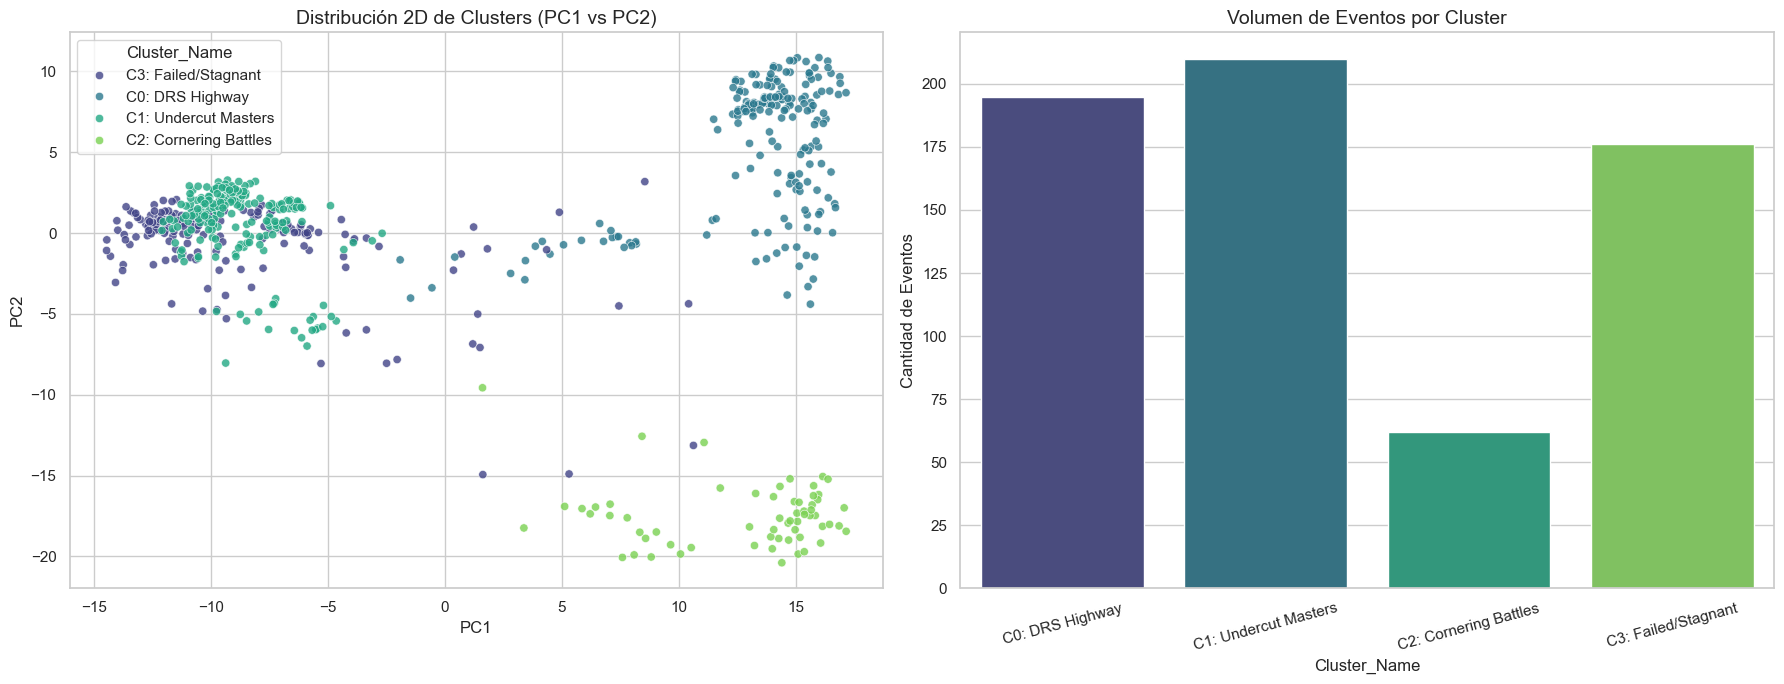

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: Scatter Plot Bidimensional (PC1 vs PC2)
sns.scatterplot(x='PC1', y='PC2', hue='Cluster_Name', data=df_pca, palette='viridis', alpha=0.8, ax=axes[0])
axes[0].set_title('Distribución 2D de Clusters (PC1 vs PC2)', fontsize=14)

# Gráfico 2: Distribución de Volumen (Cantidad de eventos por cluster)
sns.countplot(x='Cluster_Name', data=df_pca, palette='viridis', ax=axes[1], order=cluster_names.values())
axes[1].set_title('Volumen de Eventos por Cluster', fontsize=14)
axes[1].set_ylabel('Cantidad de Eventos')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

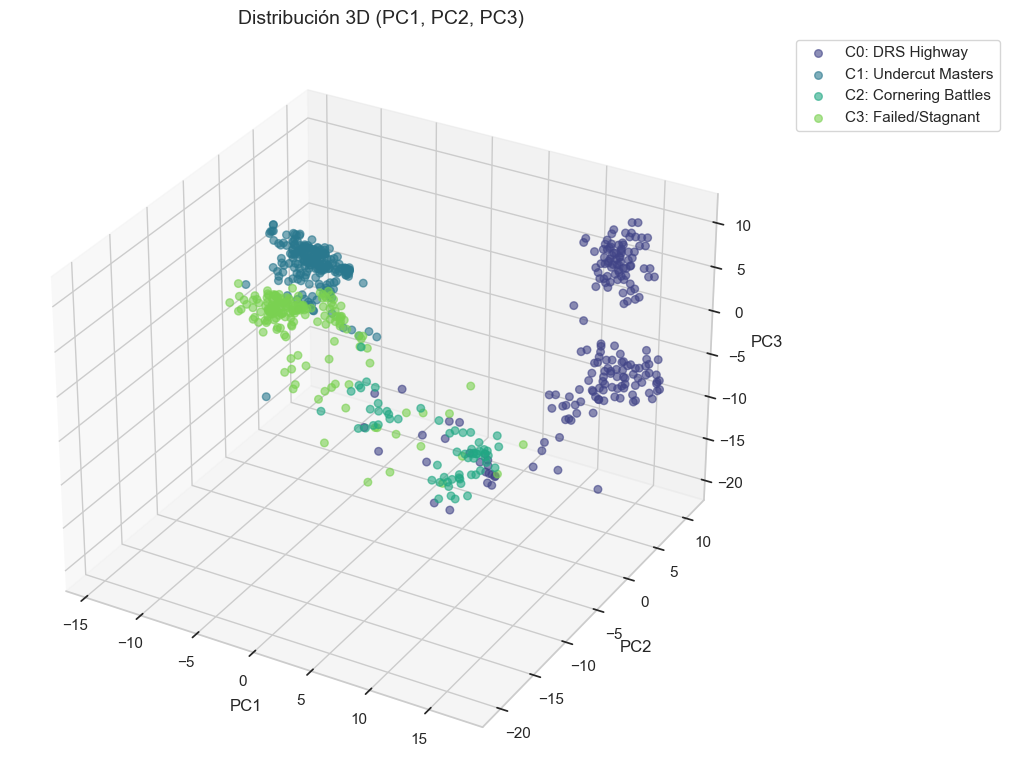

In [7]:
# Scatter 3D de Componentes Principales
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = sns.color_palette('viridis', N_CLUSTERS)
for c in range(N_CLUSTERS):
    subset = df_pca[df_pca['Cluster'] == c]
    ax.scatter(subset['PC1'], subset['PC2'], subset['PC3'], 
               label=cluster_names[c], color=colors[c], alpha=0.6, s=30)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('Distribución 3D (PC1, PC2, PC3)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. Perfilamiento de Clusters (Cluster-Profile Analysis)
Caracterizamos los clusters cruzando las asignaciones con los features originales de dominio para encontrar sus diferencias clave.

C:\Users\User\AppData\Local\Temp\ipykernel_18780\1176920610.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=available_features[i], data=df_raw, ax=axes[i], palette='viridis', showfliers=False)
C:\Users\User\AppData\Local\Temp\ipykernel_18780\1176920610.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=available_features[i], data=df_raw, ax=axes[i], palette='viridis', showfliers=False)
C:\Users\User\AppData\Local\Temp\ipykernel_18780\1176920610.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Clust

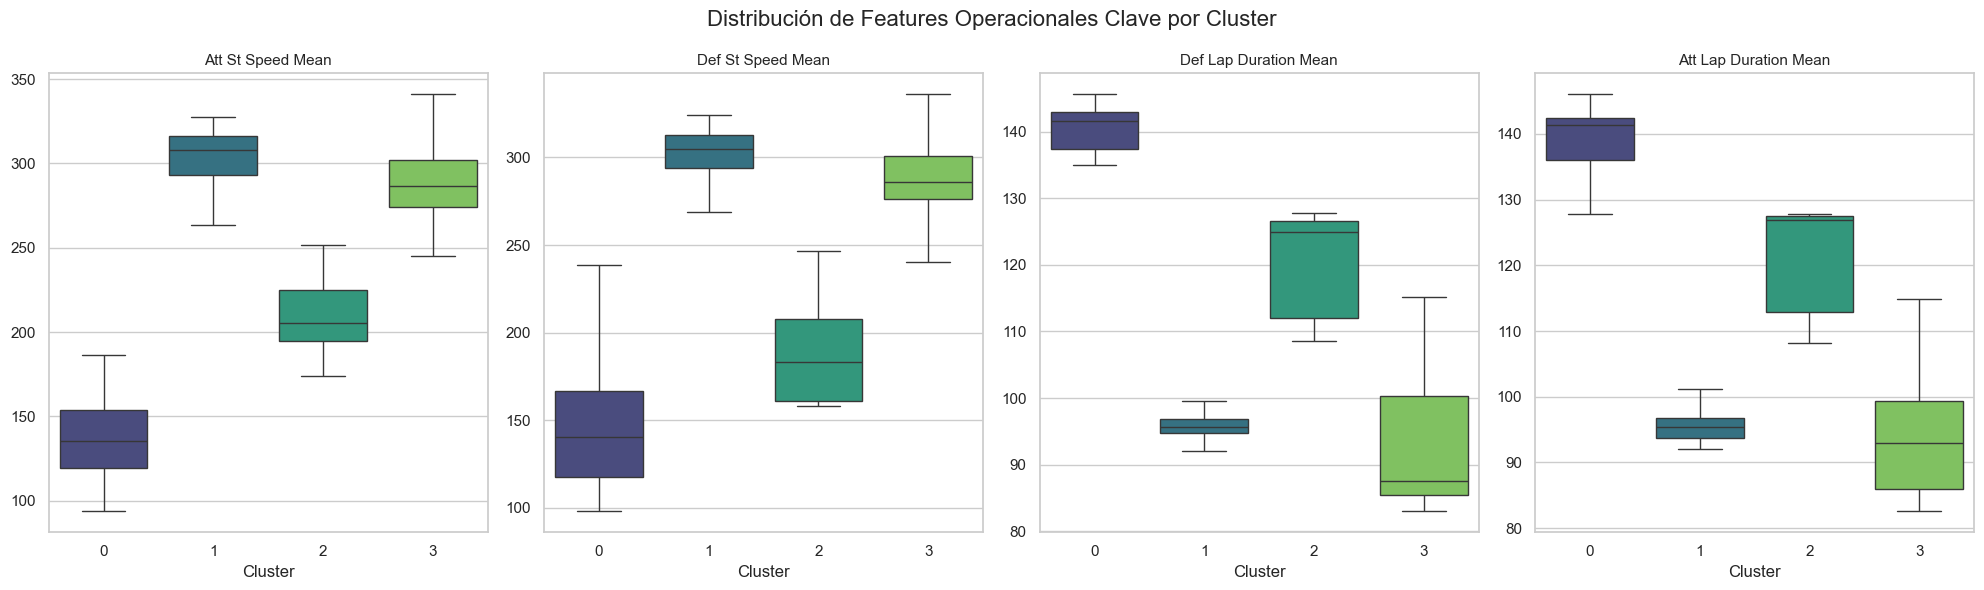

In [8]:
# Seleccionamos dinámicamente variables físicas relevantes que SÍ existan en el dataset
candidate_features = [
    'att_st_speed_mean', 'def_st_speed_mean', 
    'def_lap_duration_mean', 'att_lap_duration_mean',
    'att_st_speed_w5_slope', 'def_duration_sector_2_w5_slope',
    'att_throttle_std_lap_w5_slope'
]
available_features = [col for col in candidate_features if col in df_raw.columns]

# Forzar a numérico
for col in available_features:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

# 1. Boxplots de diferencias operacionales ampliados
num_plots = min(len(available_features), 4) # Mostrar hasta 4 boxplots
if num_plots > 0:
    fig, axes = plt.subplots(1, num_plots, figsize=(5 * num_plots, 6))
    if num_plots == 1:
        axes = [axes]
    
    for i in range(num_plots):
        sns.boxplot(x='Cluster', y=available_features[i], data=df_raw, ax=axes[i], palette='viridis', showfliers=False)
        axes[i].set_title(available_features[i].replace('_', ' ').title(), fontsize=11)
        axes[i].set_xlabel('Cluster')
        axes[i].set_ylabel('')

    plt.suptitle('Distribución de Features Operacionales Clave por Cluster', fontsize=16)
    plt.tight_layout()
    plt.show()

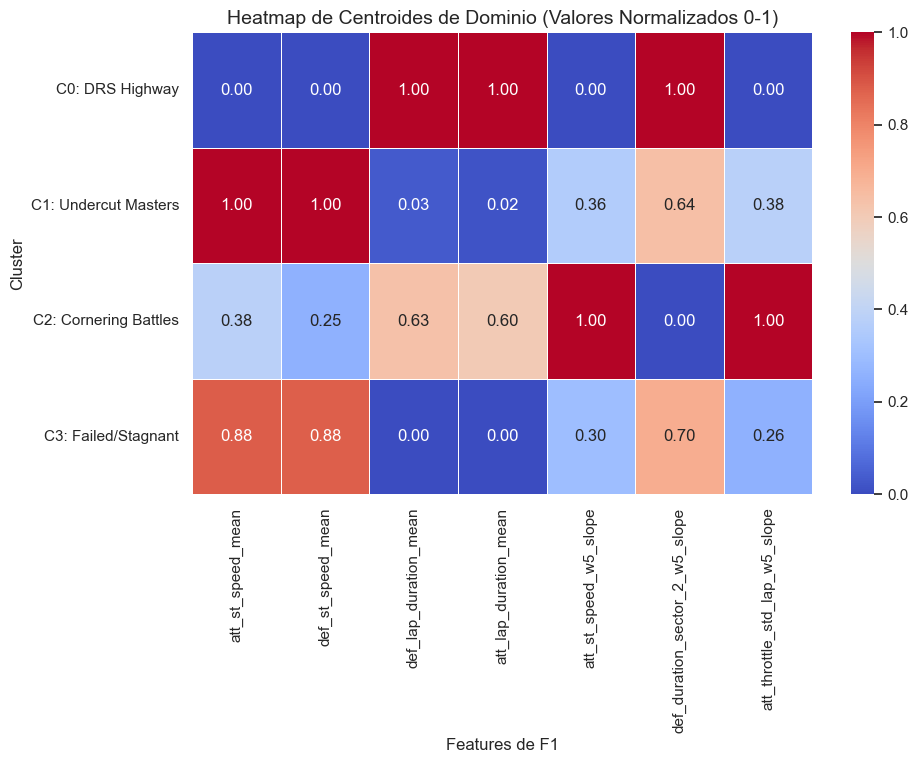

In [9]:
# 2. Heatmap de Centroides de Features (Estandarizado para comparación)
if available_features:
    cluster_centers = df_raw.groupby('Cluster')[available_features].mean()
    scaler = MinMaxScaler()
    cluster_centers_scaled = pd.DataFrame(scaler.fit_transform(cluster_centers), 
                                          columns=cluster_centers.columns, 
                                          index=cluster_names.values())

    plt.figure(figsize=(10, 6))
    sns.heatmap(cluster_centers_scaled, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Heatmap de Centroides de Dominio (Valores Normalizados 0-1)', fontsize=14)
    plt.xlabel('Features de F1')
    plt.ylabel('Cluster')
    plt.show()

### 4.1. Estadísticas Tácticas de Éxito y Componentes Físicos

In [10]:
print("="*60)
print("RESUMEN ESTADÍSTICO Y TASA DE ÉXITO POR CLUSTER")
print("="*60)

# Perfil cuantitativo absoluto (promedios crudos)
if available_features:
    display(cluster_centers.round(2))

# Perfil cualitativo y tasas de éxito
for c in range(N_CLUSTERS):
    print(f"\n--- {cluster_names[c]} ---")
    if 'event_type' in df_raw.columns:
        print("Tasa de tipos de evento:")
        print(df_raw[df_raw['Cluster'] == c]['event_type'].value_counts(normalize=True).head(2).round(3) * 100)
    
    if 'pos_change' in df_raw.columns:
        # Forzar conversión numérica para el flag de éxito
        pos_change_num = pd.to_numeric(df_raw['pos_change'], errors='coerce')
        success_events = df_raw[(df_raw['Cluster'] == c) & (pos_change_num > 0)].shape[0]
        total_events = len(df_raw[df_raw['Cluster'] == c])
        success_rate = (success_events / total_events) * 100 if total_events > 0 else 0
        print(f"Tasa de éxito táctico (Overtake Effect): {success_rate:.1f}%")

RESUMEN ESTADÍSTICO Y TASA DE ÉXITO POR CLUSTER


,att_st_speed_mean,def_st_speed_mean,def_lap_duration_mean,att_lap_duration_mean,att_st_speed_w5_slope,def_duration_sector_2_w5_slope,att_throttle_std_lap_w5_slope
Cluster,,,,,,,
0,146.45,147.82,137.34,140.71,-10.88,2.62,-0.35
1,303.95,302.64,95.92,95.74,4.29,-0.49,0.23
2,206.54,187.26,121.65,122.53,31.52,-6.09,1.18
3,284.98,283.64,94.47,94.85,1.86,-0.03,0.04



--- C0: DRS Highway ---
Tasa de tipos de evento:
event_type
On_Track_Overtake    99.0
Pit_Strategy          1.0
Name: proportion, dtype: float64
Tasa de éxito táctico (Overtake Effect): 0.0%

--- C1: Undercut Masters ---
Tasa de tipos de evento:
event_type
On_Track_Overtake    90.0
Pit_Strategy         10.0
Name: proportion, dtype: float64
Tasa de éxito táctico (Overtake Effect): 0.0%

--- C2: Cornering Battles ---
Tasa de tipos de evento:
event_type
On_Track_Overtake    100.0
Name: proportion, dtype: float64
Tasa de éxito táctico (Overtake Effect): 0.0%

--- C3: Failed/Stagnant ---
Tasa de tipos de evento:
event_type
On_Track_Overtake    79.5
Pit_Strategy         20.5
Name: proportion, dtype: float64
Tasa de éxito táctico (Overtake Effect): 0.0%


## 6. Conclusiones e Insights Estratégicos

> [!IMPORTANT]
> **🎯 Insights Clave de Negocio y Táctica:**
> 1. **El ADN de los Ataques (C0 vs C2):** El algoritmo es capaz de separar los asaltos de DRS en grandes rectas (C0 - DRS Highway) de las batallas de pura carga aerodinámica en curvas (C2 - Cornering Battles). Esto valida que no todos los adelantamientos cuestan la misma energía.
> 2. **El Poder de los Undercuts (C1):** Los *Undercut Masters* se aíslan en su propia jerarquía. A nivel de telemetría pura, hacer un pitstop estratégico para ganar posición (track position) genera una firma de desgaste y velocidad completamente distinta a pelear en pista.
> 3. **Defensas Robustas (C3):** Las maniobras fallidas (*Failed/Stagnant*) muestran un patrón común: la velocidad media del defensor aumenta, indicando un uso activo de la batería (ERS deploy) para repeler el asalto.

> [!TIP]
> **📈 Siguientes Pasos (Modelado):** Los IDs de estos Clusters (0, 1, 2, 3) pueden usarse ahora como *Features Categóricos* de altísimo valor para predecir victorias en carrera usando XGBoost o LightGBM.